In [1]:
from importlib import reload
import mlp.utils
reload(mlp.utils)
from mlp.utils import load_dataset

X, y = load_dataset("../lab1_data/Classification/data.simple.train.500.csv")


ModuleNotFoundError: No module named 'mlp'

In [8]:
from mlp.utils import load_dataset
import numpy as np

X, y = load_dataset("../lab1_data/Classification/data.simple.train.500.csv")
print("Unique labels:", np.unique(y))


[1 2]
[1 2]
Unique labels: [0 1]


In [32]:
from mlp.utils import load_dataset
import inspect

print(inspect.getsource(load_dataset))

def load_dataset(path: str):
    """
    Load a CSV dataset. Assumes all columns except the last are features (X)
    and the last column is the target (y).

    Also normalizes binary labels:
      - {1, 2} -> {0, 1}
      - {-1, 1} -> {0, 1}
    """
    df = pd.read_csv(path)
    X = df.iloc[:, :-1].to_numpy(dtype=float)
    y = df.iloc[:, -1].to_numpy()

    # --- Normalize binary labels ---
    unique_vals = np.unique(y)
    if set(unique_vals) == {1, 2}:
        y = y - 1
    elif set(unique_vals) == {-1, 1}:
        y = (y + 1) // 2

    return X, y



### Odtąd faktyczny eksperyment, powyżej jakieś tam rzeczy poboczne

In [1]:
from importlib import reload
reload(mlp.mlp)
reload(mlp.utils)
from mlp.mlp import MLP
from mlp.utils import load_dataset, accuracy, plot_loss
import numpy as np

NameError: name 'mlp' is not defined

In [28]:
X, y = load_dataset("../lab1_data/Classification/data.simple.train.500.csv")

In [29]:
net = MLP(
    layer_sizes=[X.shape[1], 8, 1],  # 2 -> 8 -> 1 for binary classification
    task="binary",
    activation="sigmoid",
    learning_rate=0.001,
    seed=0
)

losses = net.fit(X, y, epochs=5000, verbose=True)

epoch=   0  loss=0.69318438  lr=0.001
epoch= 500  loss=0.09354709  lr=0.001
epoch=1000  loss=0.05733505  lr=0.001
epoch=1500  loss=0.04485544  lr=0.001
epoch=2000  loss=0.03794768  lr=0.001
epoch=2500  loss=0.03340848  lr=0.001
epoch=3000  loss=0.03014427  lr=0.001
epoch=3500  loss=0.02766061  lr=0.001
epoch=4000  loss=0.02569545  lr=0.001
epoch=4500  loss=0.02409483  lr=0.001


In [25]:
y_pred = net.predict(X)
acc = accuracy(y, y_pred)
print(f"Training accuracy: {acc:.3f}")

Training accuracy: 0.500


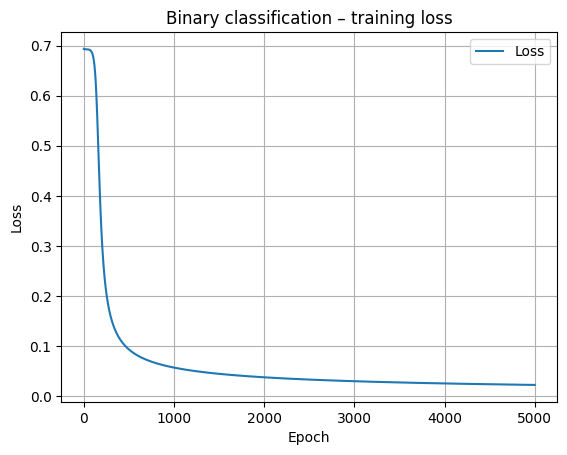

In [26]:
plot_loss(losses, title="Binary classification – training loss")